In [72]:
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.calibration import calibration_curve
from sklearn.metrics import PrecisionRecallDisplay

from inat_pipeline.train import ranking

In [91]:
# Load artifacts

# Model
with open("artifacts/model.pkl", "rb") as f:
    pipeline = pickle.load(f)

# Metrics
with open("artifacts/test_metrics.json") as f:
    metrics = json.load(f)

# Test set
X = pd.read_parquet("artifacts/X_test.parquet")
y = np.load("artifacts/y_test.npy")
y_proba = np.load("artifacts/y_proba.npy")

In [74]:
# Ranking lift
lift_df = pd.DataFrame(metrics["lift_table"])
lift_df

,k_pct,n_reviewed,recall_at_k,precision_at_k,lift_at_k
0,0.005,137,0.017222,0.985401,3.453619
1,0.010,274,0.034443,0.985401,3.453619
2,0.050,1373,0.164434,0.938820,3.290361
3,0.100,2747,0.306162,0.873680,3.062061
4,0.200,5494,0.524812,0.748817,2.624441
5,0.500,13737,0.886720,0.506006,1.773440


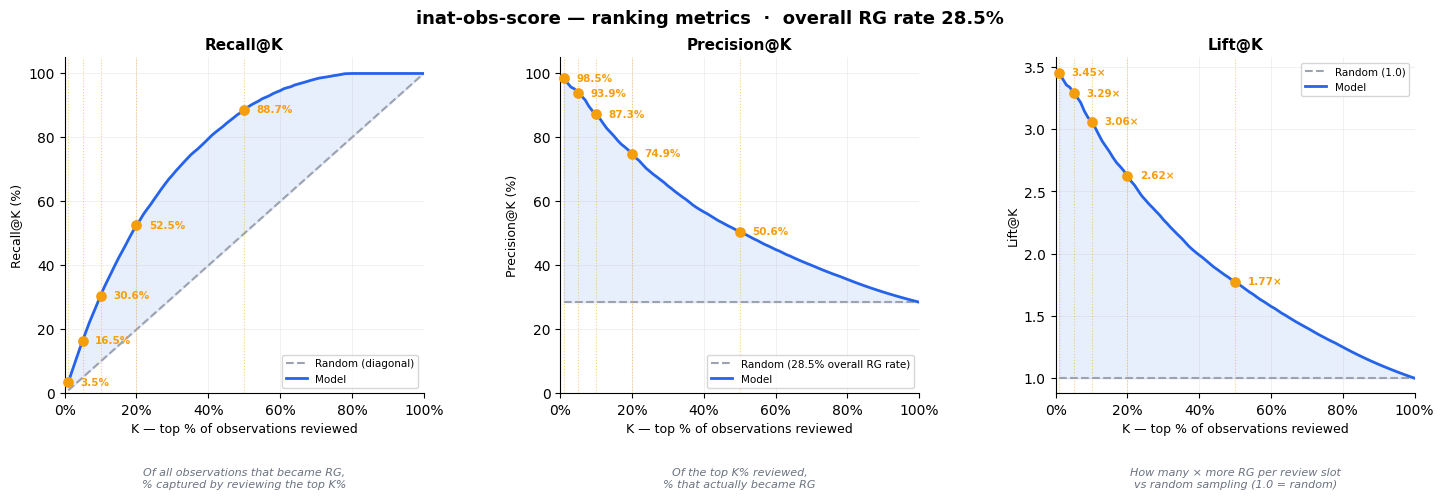

In [75]:
# Ranking metrics
k_values = [0.01, 0.05, 0.1, 0.2, 0.5]
curves = ranking.compute_ranking_curves(y, y_proba)
rg_rate = curves["baseline_precision"].iloc[0]
suffix = f"  ·  overall RG rate {rg_rate * 100:.1f}%"
title = f"inat-obs-score — ranking metrics{suffix}"
ranking.plots.plot_ranking_curves(curves, title=title, highlight_k=k_values)

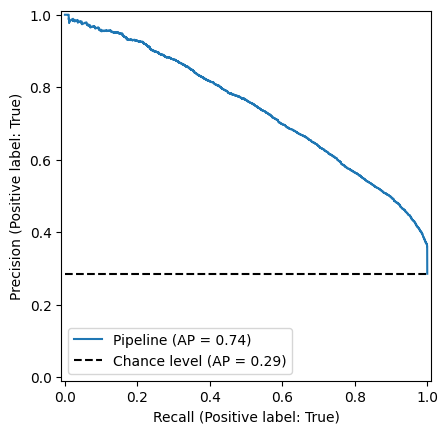

In [ ]:
# PrecisionRecall
pr = PrecisionRecallDisplay.from_estimator(
    pipeline, X, y, plot_chance_level=True, response_method="predict_proba"
)
plt.show()

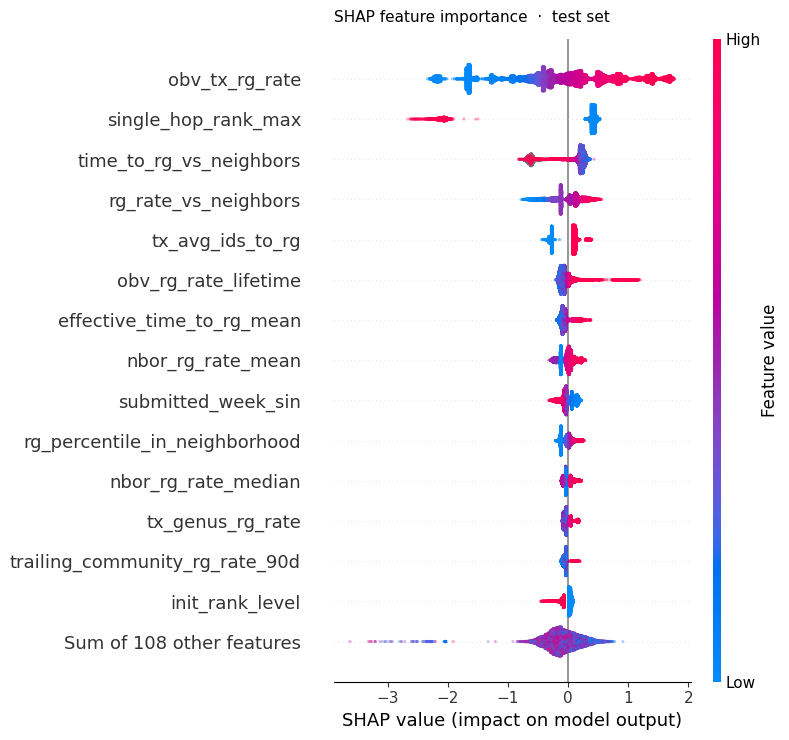

In [93]:
# Shap
shap_vals = np.load("artifacts/shap_values.npy")
feature_names = list(pipeline.named_steps["preprocessor"].get_feature_names_out())
explanation = shap.Explanation(
    values=shap_vals, data=X.values, feature_names=X.columns.tolist()
)


fig, ax = plt.subplots(figsize=(10, 5))
shap.plots.beeswarm(explanation, max_display=15, s=5, alpha=0.33, show=False)
plt.title("SHAP feature importance  ·  test set", fontsize=11, loc="left", pad=12)
plt.tight_layout()

Brier Score : 0.13361501122929748


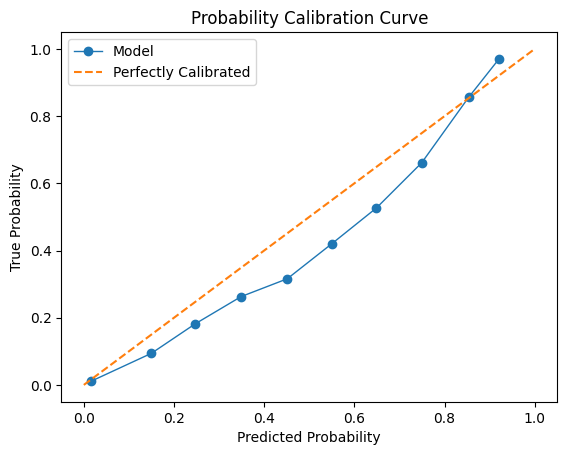

In [78]:
# Brier
print("Brier Score :", metrics["brier_score"])
true_pos, pred_pos = calibration_curve(y, y_proba, n_bins=10)
# Plot the Probabilities Calibrated curve

# Plot the Probabilities Calibrated curve
plt.plot(pred_pos, true_pos, marker="o", linewidth=1, label="Model")

# Plot the Perfectly Calibrated by Adding the 45-degree line to the plot
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly Calibrated")


# Set the title and axis labels for the plot
plt.title("Probability Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")

# Add a legend to the plot
plt.legend(loc="best")
plt.show()